<a href="https://colab.research.google.com/github/gauravprajapati9210/Machine-Learning-Projects/blob/main/SmartCart_clustering_sys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SmartCart clustering System
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("smartcart_customers.csv")
df.shape


(2240, 22)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [ ]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing


Handle the missing values


In [ ]:
df["Income"]=df["Income"].fillna(df["Income"].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [ ]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tanure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [ ]:
#Total_Spending
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntFishProducts"]+ df["MntMeatProducts"] + df["MntSweetProducts"]+ df["MntGoldProds"]


In [ ]:
df["Total_Children"] = df["Kidhome"]+ df["Teenhome"]

In [ ]:
# Education
df["Education"]=df["Education"].replace({
    "Basic": "Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate","Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [ ]:
df ["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [ ]:
# Marital status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [ ]:
df["Living_With"]=df["Marital_Status"].replace({
    "Married ": "Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [ ]:
df["Living_With"].value_counts()

Living_With
Married    864
Alone      796
Partner    580
Name: count, dtype: int64

In [ ]:
#Drop columns
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntFishProducts","MntMeatProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [ ]:
df_cleaned.shape

(2240, 15)

In [ ]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tanure_Days,Total_spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Married


# Outliers

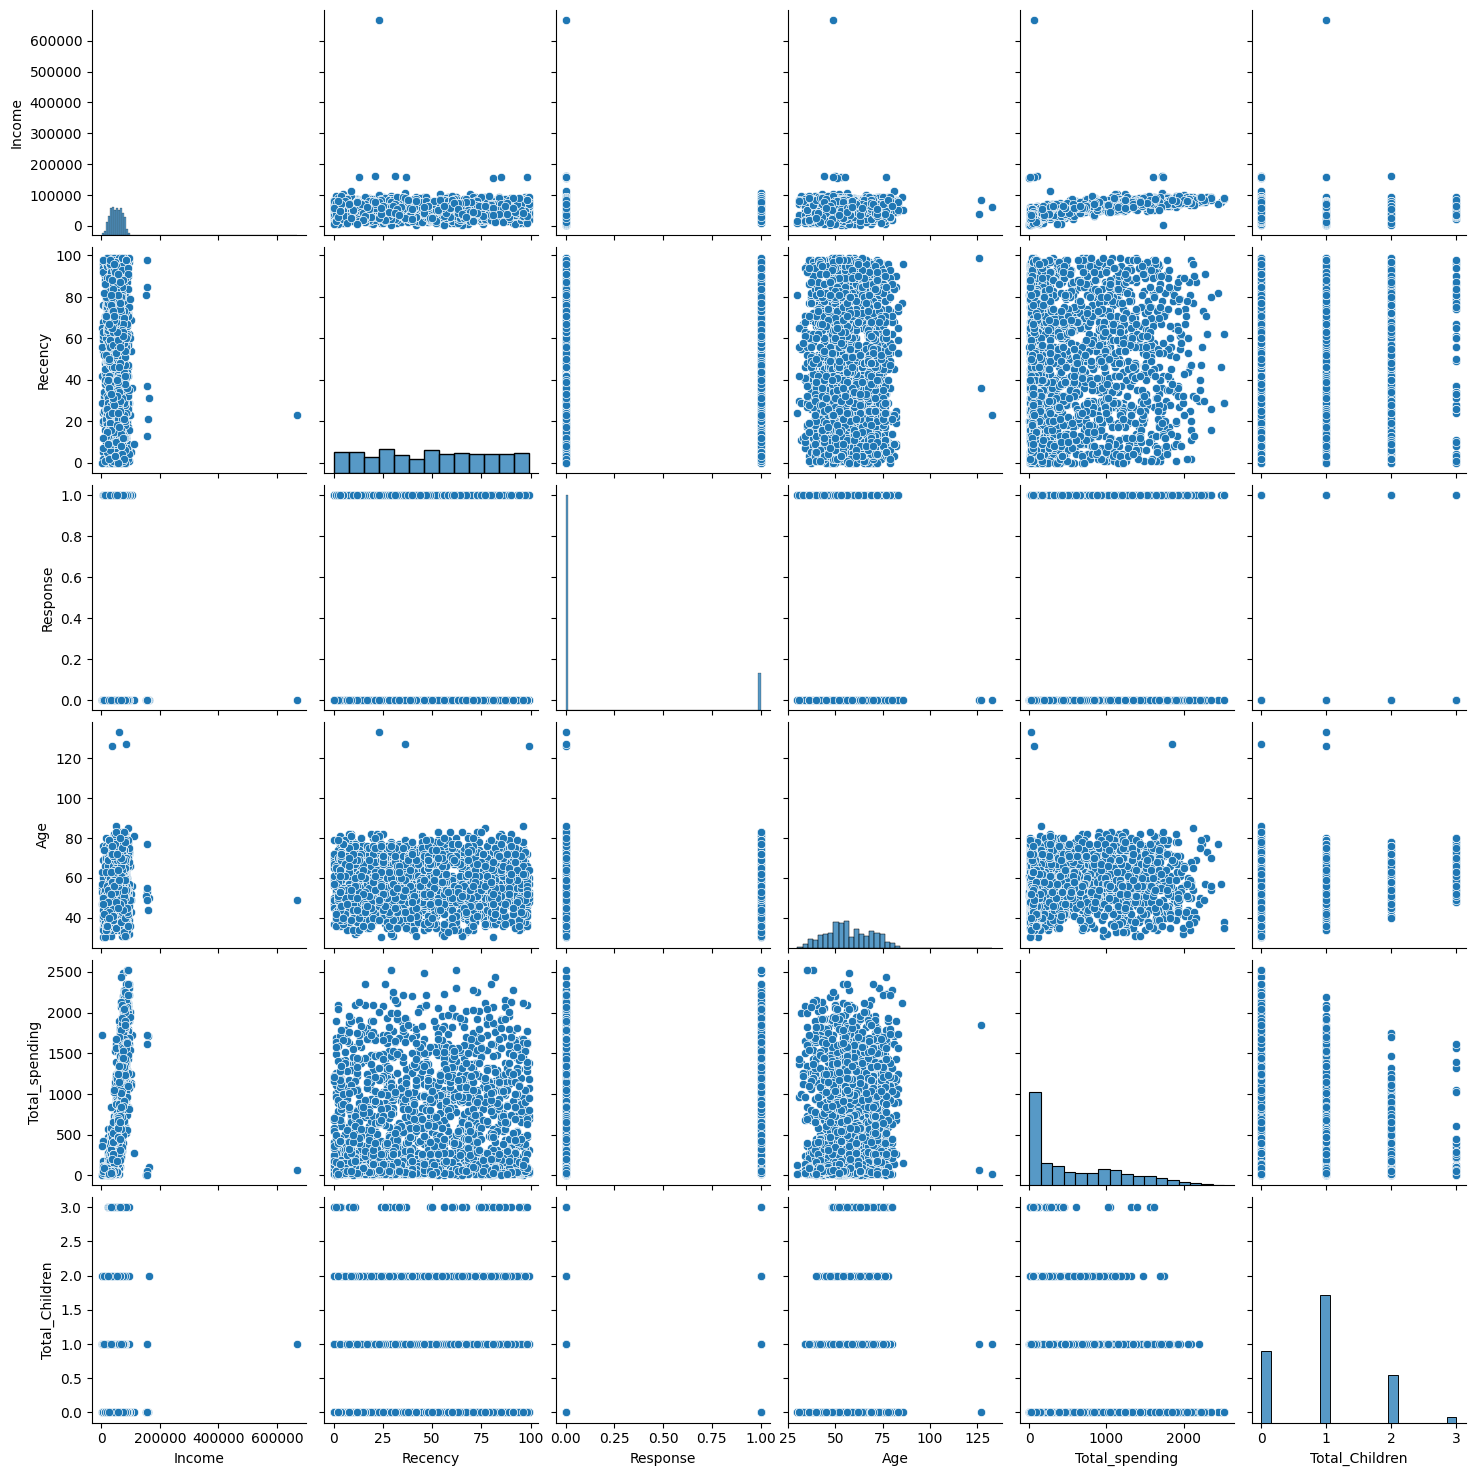

In [ ]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_Children"]
# relative plots of some features -
sns.pairplot(df_cleaned[cols])

In [ ]:
# Remove outliers
print("data Size with outliers",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<80)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("data Size with outliers",len(df_cleaned))

data Size with outliers 2240
data Size with outliers 2196


In [ ]:
#HeatMaps
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

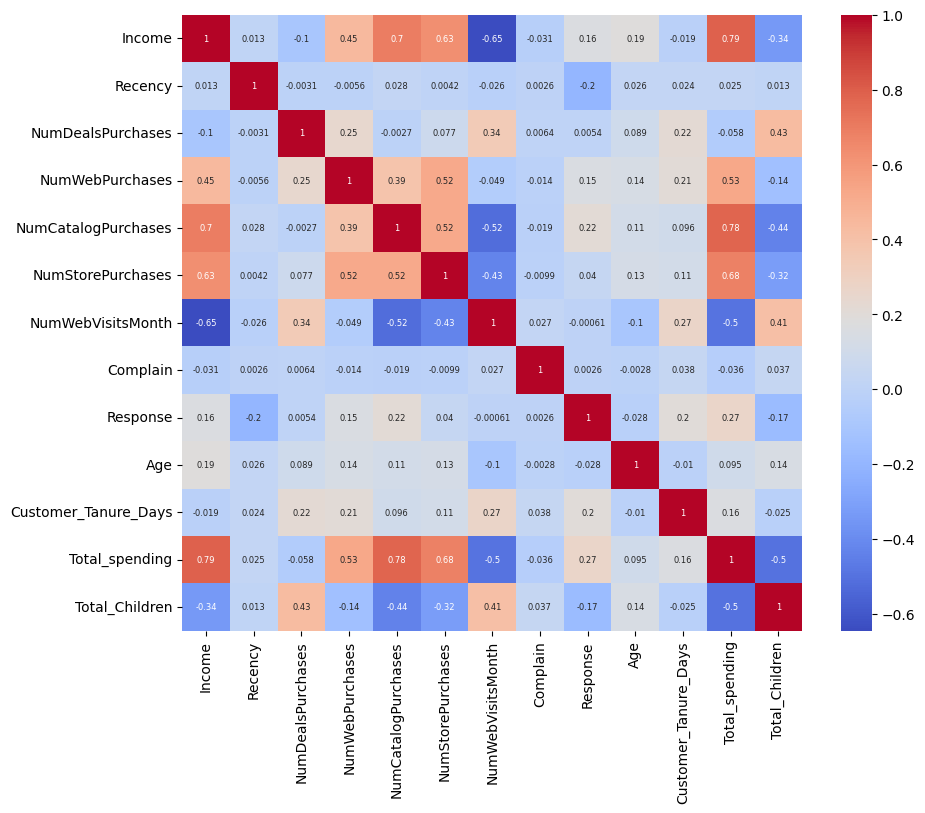

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,annot = True, annot_kws ={"size":6},
    cmap = "coolwarm"
)

In [ ]:
#Encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)


In [ ]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols),enc_df], axis =1)

In [ ]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tanure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Married,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0.0


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
x = df_encoded
scaler = StandardScaler()
x_scaled=scaler.fit_transform(x)

# Visualization

In [ ]:
# 2d visualization
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
x_pca  = pca.fit_transform(x_scaled)
pca.explained_variance_ratio_

array([0.21902787, 0.09902376, 0.09469954])

Text(0.5, 0.92, '3D projection')

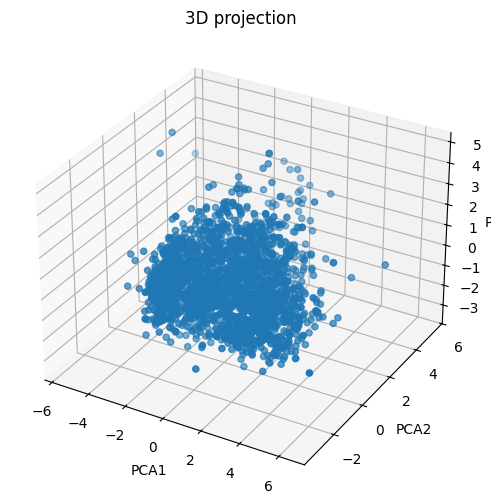

In [ ]:
# plot]
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

In [ ]:
pca.explained_variance_ratio_

array([0.21902787, 0.09902376, 0.09469954])

# Analysis of K value
1. Elbow method


In [ ]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [ ]:
knee=KneeLocator(range(1,11),wcss,curve = "convex",direction = "decreasing")
optimal_k = knee.elbow

In [ ]:
print("Best K :",optimal_k)

Best K : 3


Text(0, 0.5, 'WCSS')

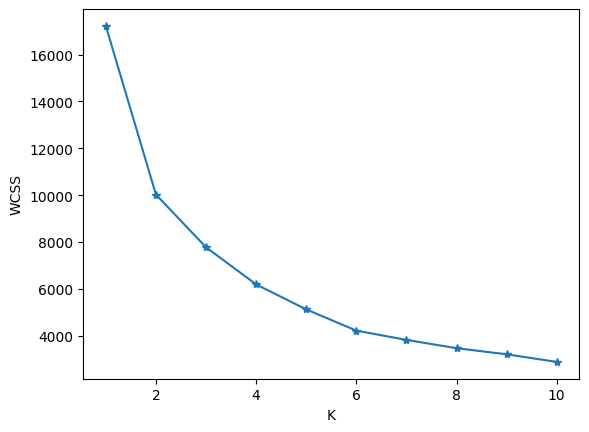

In [ ]:
# plot
plt.plot(range(1,11),wcss,marker ="*")
plt.xlabel("K")
plt.ylabel("WCSS")

2.Silhouette Score


In [ ]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)


Text(0, 0.5, 'silhouette_score')

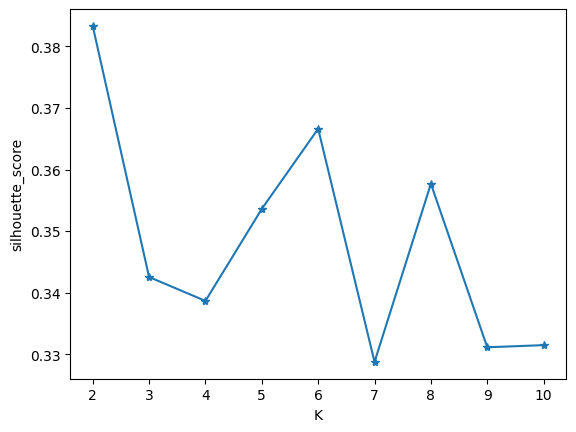

In [ ]:
#plot
plt.plot(range(2,11),scores,marker="*")
plt.xlabel("K")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'ss')

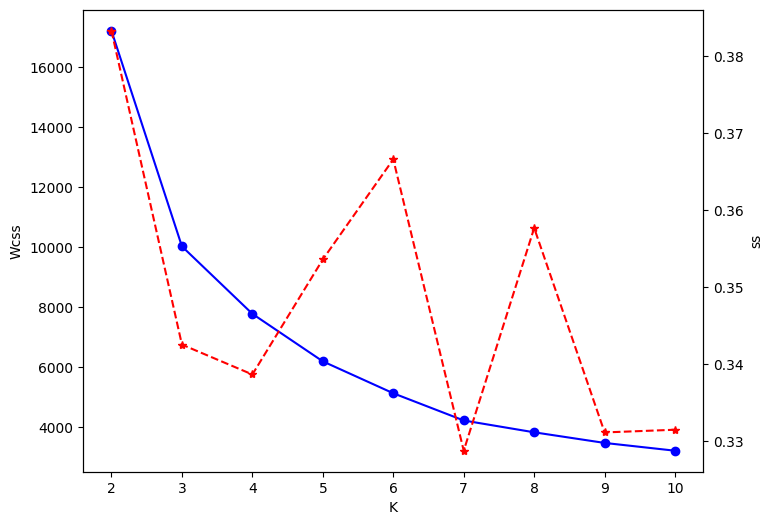

In [ ]:
# combined plot
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker = 'o',color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("Wcss")
ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker ="*",color ="red",linestyle="--")
ax2.set_ylabel("ss")

# Clustering

In [ ]:
# k_means
kmeans = KMeans(n_clusters = 4,random_state = 42)
labels_kmeans = kmeans.fit_predict(x_pca)

Text(0.5, 0.92, '3D projection')

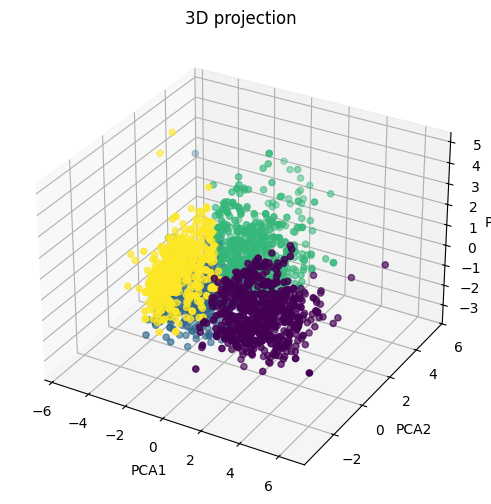

In [ ]:
# plot]
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

In [ ]:
# Agglomarative clustering
from sklearn.cluster import AgglomerativeClustering



In [ ]:
agg_clf = AgglomerativeClustering(n_clusters = 4,linkage = "ward")
labels_agg= agg_clf.fit_predict(x_pca)

Text(0.5, 0.92, '3D projection')

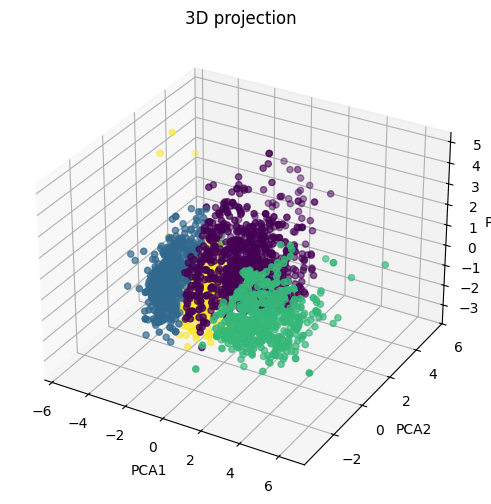

In [ ]:
# plot]
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

# characterizations of clusters

In [ ]:
df_cleaned.drop("labels",axis=1)
df_cleaned["cluster"] = labels_agg


<Axes: xlabel='cluster', ylabel='count'>

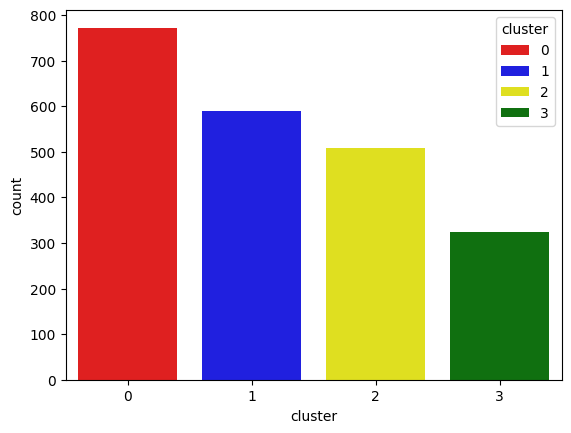

In [ ]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["cluster"],palette = pal,hue=df_cleaned["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

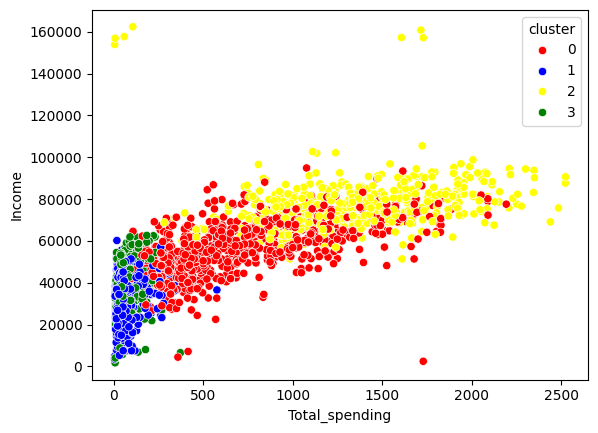

In [ ]:
# check Income & spending patterns
sns.scatterplot(x=df_cleaned["Total_spending"],y = df_cleaned["Income"],hue = df_cleaned["cluster"],palette = pal)

1 --> blue --> low / moderate Income
low / modrate spending

2--> yellow -->  high Income
high spending

3--> green --> low Income
              low spending
4 --> red --> Moderate - High Income
              high spending

In [ ]:
# cluster summery
cluster_summary = x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        56641.850389  49.270725           3.566062         6.075130   
1        30711.928814  49.725424           1.988136         1.874576   
2        77760.450884  50.088409           1.141454         4.868369   
3        37481.487692  46.726154           1.950769         1.916923   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   2.977979           7.270725           5.830311  0.007772   
1                   0.406780           2.983051           6.683051  0.018644   
2                   6.066798           8.394892           2.438114  0.003929   
3                   0.510769           3.110769           6.295385  0.000000   

         Response        Age  Customer_Tanure_Days  Total_spending  \
cluster         